# Exercice 1

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [5]:
# Load the dataset
url = "https://hastie.su.domains/ElemStatLearn/datasets/SAheart.data"
data = pd.read_csv(url)

print(data)

     row.names  sbp  tobacco    ldl  adiposity  famhist  typea  obesity  \
0            1  160    12.00   5.73      23.11  Present     49    25.30   
1            2  144     0.01   4.41      28.61   Absent     55    28.87   
2            3  118     0.08   3.48      32.28  Present     52    29.14   
3            4  170     7.50   6.41      38.03  Present     51    31.99   
4            5  134    13.60   3.50      27.78  Present     60    25.99   
..         ...  ...      ...    ...        ...      ...    ...      ...   
457        459  214     0.40   5.98      31.72   Absent     64    28.45   
458        460  182     4.20   4.41      32.10   Absent     52    28.61   
459        461  108     3.00   1.59      15.23   Absent     40    20.09   
460        462  118     5.40  11.61      30.79   Absent     64    27.35   
461        463  132     0.00   4.82      33.41  Present     62    14.70   

     alcohol  age  chd  
0      97.20   52    1  
1       2.06   63    1  
2       3.81   46    0  

In [6]:
# Drop the 'row.names' column as it is not needed
data.drop('row.names', axis = 1, inplace = True)

# Encode categorical variables
data['famhist'] = LabelEncoder().fit_transform(data['famhist'])

# Prepare features and target
X = data.drop('chd', axis = 1)
y = data['chd']

print(X)
print(y)

     sbp  tobacco    ldl  adiposity  famhist  typea  obesity  alcohol  age
0    160    12.00   5.73      23.11        1     49    25.30    97.20   52
1    144     0.01   4.41      28.61        0     55    28.87     2.06   63
2    118     0.08   3.48      32.28        1     52    29.14     3.81   46
3    170     7.50   6.41      38.03        1     51    31.99    24.26   58
4    134    13.60   3.50      27.78        1     60    25.99    57.34   49
..   ...      ...    ...        ...      ...    ...      ...      ...  ...
457  214     0.40   5.98      31.72        0     64    28.45     0.00   58
458  182     4.20   4.41      32.10        0     52    28.61    18.72   52
459  108     3.00   1.59      15.23        0     40    20.09    26.64   55
460  118     5.40  11.61      30.79        0     64    27.35    23.97   40
461  132     0.00   4.82      33.41        1     62    14.70     0.00   46

[462 rows x 9 columns]
0      1
1      1
2      0
3      1
4      1
      ..
457    0
458    1
459 

In [7]:
# Create and train the 3-NN model
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X, y)

# Predict on the training set for resubstitution error
y_pred_knn = knn.predict(X)
resub_error_knn = 1 - accuracy_score(y, y_pred_knn)

print(f"Resubstitution error rate: {round(resub_error_knn * 100, 3)}%")

Resubstitution error rate: 24.026%


In [8]:
# Calculate 10-fold CV error
cv_scores_knn = cross_val_score(knn, X, y, cv = 10)
cv_error_knn = 1 - cv_scores_knn.mean()

print(f"10CV error rate: {round(cv_error_knn * 100, 3)}%")

10CV error rate: 41.559%


In [9]:
# Create and train the RF model
rf = RandomForestClassifier(n_estimators = 100)
rf.fit(X, y)

# Predict on the training set for resubstitution error
y_pred_rf = rf.predict(X)
resub_error_rf = 1 - accuracy_score(y, y_pred_rf)

print(f"Resubstitution error rate: {round(resub_error_rf * 100, 3)}%")

Resubstitution error rate: 0.0%


In [10]:
# Calculate 10-fold CV error
cv_scores_rf = cross_val_score(rf, X, y, cv = 10)
cv_error_rf = 1 - cv_scores_rf.mean()

print(f"10CV error rate: {round(cv_error_rf * 100, 3)}%")

10CV error rate: 30.301%


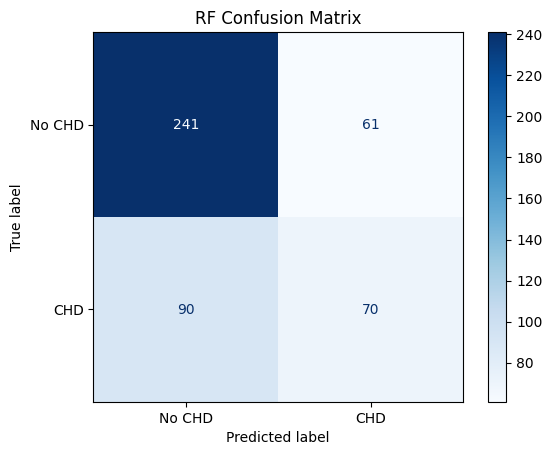

In [11]:
# Confusion matrix
y_pred_rf = cross_val_predict(rf, X, y, cv = 10)
cm = confusion_matrix(y, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CHD', 'CHD'])
disp.plot(cmap=plt.cm.Blues)
plt.title('RF Confusion Matrix')
plt.show()